This is my first jupyter notebook. I used for getting the spectras out of the photoluminescence measurements for the TFM Results chapter. The objective is to get the data from the database file, do some fits with scipy curve fit and plot the results. Different plots are performed.

In [1]:
import qcodes as qc
from qcodes.dataset import load_by_id
import matplotlib.pyplot as plt
from qcodes.dataset.experiment_container import experiments

%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.signal import medfilt
import matplotlib.pyplot as plt
import os

def gaussian(x, amp, x0, sigma):
    return  amp*np.exp(-(x - x0)**2/(2 * sigma**2))

def lorentzian(x, amp, x0, gamma):
    return amp*gamma**2/((x-x0)**2+gamma**2) 

def pv(x,A,eta,x0,w, offset):
    """
    A: Altura total del pico (sobre el offset)
    x0: Posición central del máximo
    sigma: Anchura de la Gaussiana
    gamma: Anchura de la Lorentziana
    eta: Peso de la Lorentziana (0 = puramente Gaussiana, 1 = puramente Lorentziana)
    offset: Ruido de fondo (línea base)

    """
    sigma = w/2.35482
    gamma=w/2.0
    g = gaussian(x, 1, x0, sigma)
    l = lorentzian(x, 1, x0, gamma)
    return A*(eta*l+(1-eta)*g)+offset

In [3]:

def peak_track(x_data, y, y_mask_fit=0,mode1=True):
    if mode1:
        y_mask_fit=y
    A_guess = np.max(y)-np.min(y)
    x0_guess = x_data[np.argmax(y_mask_fit)]
    offset_guess = np.min(y)
    w_guess=50.0
    p0 = [A_guess, 0.5, x0_guess, w_guess, offset_guess]
    limits = ([0,0,0,0.1, 0],[np.inf, 1, 1600, np.inf, np.inf])
    try:
        popt, pcov = curve_fit(pv, x_data, y, p0=p0, bounds = limits)
        A = popt[0]
        x = popt[2]
    except RuntimeError:
        A = np.nan
        x = np.nan
        print('ERROR: curve_fit failed for this spectrum')
        popt =[np.nan,np.nan,np.nan,np.nan,np.nan]
        pcov=np.nan
    return A, x, popt, pcov 

The following script plots every spectra out of some id of the database and saves it in a folder. It also fits every spectra and outputs the R^2 value. I used it to take a glimpse out of the spectras inside and outside the CIPS substrate and also to ensure the fitting functions worked. The output indexes are reversed, i.e., the point (5,2) corresponds to the point (2,5) on the map.

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import medfilt

# 1. Creamos una carpeta para guardar las fotos (si ya existe, no hace nada)
carpeta_salida = r"G:\Mi unidad\Experiments\Materials\Multiferroic\hm_zarcillo\08_measurements\20260721\SPECTRA"
os.makedirs(carpeta_salida, exist_ok=True)
x_data = xr_data['camera_pixel_x_axis'].values
y_matrix = xr_data['camera_spectrum'].values
# 2. Definimos la ventana (ROI) fuera del bucle
filtro=(x_data > 100) & (x_data < 1400)                  
x_fit = x_data[filtro]

print(f"ROI definida: {x_fit[0]} a {x_fit[-1]} pixeles")
k=1

for i in range(15):
    for j in range(15):
        
        # --- A) EXTRACCIÓN Y LIMPIEZA ---
        y_crudo = y_matrix[i, j, :]
        noise_treshold = 253
        
        
        # big filter to try and erase the peaks
        y_plantilla = medfilt(y_crudo, kernel_size=51)
        
        dif = y_crudo - y_plantilla
        
        mask = dif > noise_treshold
        
        y_limpio = y_crudo.copy()
        
        y_limpio[mask] = y_plantilla[mask]
        # Aplicamos la ventana
        y_zone = y_limpio[filtro]
        x_zone=x_fit
        y_plantilla_zone=y_plantilla[filtro]
        
        
        try:
            # Hacemos el ajuste
            a,x, popt, pcov = peak_track(x_zone, y_zone,y_mask_fit=y_plantilla_zone, mode1=False)
            y_fit = pv(x_zone, *popt)
            
            # Calculamos R^2 para ponerlo en el título
            residuos = y_zone - y_fit
            ss_res = np.sum(residuos**2)
            ss_tot = np.sum((y_zone - np.mean(y_zone))**2)
            r_cuadrado = 1 - (ss_res / ss_tot)
            
            # (Usamos un tamaño un poco más compacto para los JPGs)
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
            # Arriba: Datos y Ajuste
            ax1.plot(x_data, y_crudo, 'b.', label='signal', alpha=0.5)
            ax1.plot(x_zone, y_fit, 'r-', label='Fit', linewidth=2)
            ax1.set_ylabel("Counts")
            ax1.set_title(f"Point (x:{i}, y:{j}) | x0={popt[2]:.1f} | R²={r_cuadrado:.3f}")
            ax1.legend()
            
            # Abajo: Residuos
            ax2.plot(x_zone, residuos, 'k-', alpha=0.6)
            ax2.axhline(0, color='red', linestyle='--')
            ax2.set_xlabel("pixel")
            ax2.set_ylabel("residues")
            
            plt.tight_layout()
            
            
            # --- D) GUARDAR Y CERRAR ---
            # Formamos el nombre del archivo (ej: punto_0_0.jpg, punto_0_1.jpg...)
            nombre_archivo = f"{carpeta_salida}/spectra_{i}_{j}.jpg"
            
            # Guardamos con buena resolución (dpi=150)
            plt.savefig(nombre_archivo, dpi=150, bbox_inches='tight')
            
            # ¡CRÍTICO! Cerramos la figura para que no se sature la memoria
            plt.close(fig)
            k+=1
        except RuntimeError:
            print(f"Curve fit failed for point (x:{i}, y:{j}). Skipping this point.")
            # Si quieres que guarde una foto vacía avisando, podrías hacerlo, 
            # pero lo normal es simplemente saltarlo.
            
print(f" all the spectra have been saved in the folder {carpeta_salida}")


NameError: name 'xr_data' is not defined

The following script filters the spectra with the best performance (threshold is above 0.95) and plots the spectrum with the highest intensity.

In [5]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import medfilt


x_data = xr_data['camera_pixel_x_axis'].values
y_matrix = xr_data['camera_spectrum'].values

# 2. Definimos la ventana (ROI) fuera del bucle
filtro=(x_data > 100) & (x_data < 1400)                  
x_fit = x_data[filtro]
intensity_max = 0
print(f"ROI definida: {x_fit[0]} a {x_fit[-1]} pixeles")

indexes = [0,0]

for i in range(y_matrix.shape[0]):
    for j in range(y_matrix.shape[1]):
        
        # --- A) EXTRACCIÓN Y LIMPIEZA ---
        y_crudo = y_matrix[i, j, :]
        noise_treshold = 253
        
        
        # big filter to try and erase the peaks
        y_plantilla = medfilt(y_crudo, kernel_size=51)
        
        dif = y_crudo - y_plantilla
        
        mask = dif > noise_treshold
        
        y_limpio = y_crudo.copy()
        
        y_limpio[mask] = y_plantilla[mask]
        # Aplicamos la ventana
        y_zone = y_limpio[filtro]
        x_zone=x_fit
        y_plantilla_zone=y_plantilla[filtro]
        y_max = np.max(y_zone)
        
        try:
            # Hacemos el ajuste
            a,x, popt, pcov = peak_track(x_zone, y_zone,y_mask_fit=y_plantilla_zone, mode1=False)
            y_fit = pv(x_zone, *popt)
            
            # Calculamos R^2 para ponerlo en el título
            residuos = y_zone - y_fit
            ss_res = np.sum(residuos**2)
            ss_tot = np.sum((y_zone - np.mean(y_zone))**2)

            r2 = 1 - (ss_res / ss_tot)

            if r2 > 0.95 and y_max > 2000: #r2 and intensity thresholds to consider a good signal
                print(f"Point (x:{i}, y:{j}) has a good fit with R²={r2:.3f} and maximum intensity {y_max:.2f}.")
            if y_max > intensity_max:
                intensity_max = y_max
                indexes = [i,j] #save the indexes of the maximum intensity value within an r2 value above the threshold 
            
         
        except RuntimeError:
            print(f"Curve fit failed for point (x:{i}, y:{j}). Skipping this point.")
            # Si quieres que guarde una foto vacía avisando, podrías hacerlo, 
            # pero lo normal es simplemente saltarlo.
            
points_in_um = 5/429.225*np.array([1944, 1957]/np.array([y_matrix.shape[0], y_matrix.shape[1]])*np.array([indexes[0], indexes[1]]))

# Plot the best fit spectrum

y_crudo = y_matrix[indexes[0], indexes[1], :] #raw spectrum

noise_treshold = 253 
y_plantilla = medfilt(y_crudo, kernel_size=51) # big median filter to try and erase the narrow peaks (noise and cosmic rays)

dif = y_crudo - y_plantilla #dif = narrow peaks and noise
mask = dif > noise_treshold # Boolean mask for the narrow peaks and noise
y_limpio = y_crudo.copy() 
y_limpio[mask] = y_plantilla[mask] #substite the narrow peaks and noise with the smoothed version

# ROI window

y_zone = y_limpio[filtro] 
x_zone=x_fit  #x_data inside the ROI
y_plantilla_zone=y_plantilla[filtro] #y_data inside the ROI

#fit the cleaned spectrum
a,x, popt, pcov = peak_track(x_zone, y_zone,y_mask_fit=y_plantilla_zone, mode1=False)
y_fit = pv(x_zone, *popt)
# Calculate R^2 again
residuos = (y_zone - y_fit)
std_residuos = residuos/np.std(residuos) #standardized residuals
ss_res = np.sum(residuos**2)    
ss_tot = np.sum((y_zone - np.mean(y_zone))**2)

r2 = 1 - (ss_res / ss_tot)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
# Arriba: Datos y Ajuste
ax1.plot(x_data, y_crudo, 'b.', label='signal', alpha=0.5)
ax1.plot(x_zone, y_fit, 'r-', label='Fit', linewidth=2)
ax1.set_ylabel("Counts")
ax1.set_title(f"Point (x:{points_in_um[1]:.2f}, y:{points_in_um[0]:.2f}) | x0={popt[2]:.1f} | R²={r2:.3f}")
ax1.legend()

# Abajo: Residuos
ax2.plot(x_zone, std_residuos, 'k-', alpha=0.6)
ax2.axhline(0, color='red', linestyle='--')
ax2.axhline(2, color='gray', linestyle=':', alpha=0.5)
ax2.axhline(-2, color='gray', linestyle=':', alpha=0.5)
ax2.set_xlabel("pixel")
ax2.set_ylabel("standardized residuals (\u03C3)")

plt.tight_layout()
plt.show()


NameError: name 'xr_data' is not defined

In [4]:
# We want to compare 2 spectra from id(11) one with CIPS beneath and one without CIPS beneath. We will use the same fitting function to compare the two spectra.
# Select the two spectra by their coordinates in the 2D map. So we will use spectra (1,1) and (2,5) (see map). The first spectrum (1,1) is the one without CIPS beneath
# and the second spectrum (2,5) is the one with CIPS beneath. 

x_data = xr_data['camera_pixel_x_axis'].values
y_matrix = xr_data['camera_spectrum'].values

# 2. Definimos la ventana (ROI) fuera del bucle
filtro=(x_data > 100) & (x_data < 1400)                  
x_fit = x_data[filtro]
intensity_max = 0
print(f"ROI definida: {x_fit[0]} a {x_fit[-1]} pixeles")

indexes = np.array([[1,1],[5,2],[9,5]])


#Create the figure outside the loop to plot both spectra in the same figure
fig, ax = plt.subplots(figsize=(8, 6))
#some labels and colors for the two spectra
colours = ['b.', 'g.', 'm.']
colors_fit = ['r-', 'orange', 'purple']
labels = ["WSe2", "CIPS/WSe2", "CIPS/WSe2"]

counter = 0

for i in indexes:
        
    # ---Get the data ---
    y_crudo = y_matrix[i[0], i[1], :]


    noise_treshold = 253
    # big filter to try and erase the peaks
    y_plantilla = medfilt(y_crudo, kernel_size=51)
    
    dif = y_crudo - y_plantilla
    
    mask = dif > noise_treshold
    
    y_limpio = y_crudo.copy()
    
    y_limpio[mask] = y_plantilla[mask]
    # Aplicamos la ventana
    y_zone = y_limpio[filtro]
    x_zone=x_fit
    y_plantilla_zone=y_plantilla[filtro]
    y_max = np.max(y_zone)
    
    try:
        # Hacemos el ajuste
        a,x, popt, pcov = peak_track(x_zone, y_zone,y_mask_fit=y_plantilla_zone, mode1=False)
        y_fit = pv(x_zone, *popt)
        
        # Calculamos R^2 para ponerlo en el título
        residuos = y_zone - y_fit
        ss_res = np.sum(residuos**2)
        ss_tot = np.sum((y_zone - np.mean(y_zone))**2)

        r2 = 1 - (ss_res / ss_tot)
        std_residuals = residuos/np.std(residuos) #standardized residuals

        # Plot the data and the fit for each spectrum

        
        ax.plot(x_data, y_crudo, colours[counter], alpha=0.5, label=f'Signal ({i[0]},{i[1]}) {labels[counter]}  | I_Max={y_max:.2f}')
        ax.plot(x_zone, y_fit, colors_fit[counter], linewidth=2, label=f'Fit ({i[0]},{i[1]}) | R²={r2:.3f}')
        counter += 1

    except RuntimeError:
        print(f"Curve fit failed for point (x:{i[0]}, y:{i[1]}). Skipping this point.")


ax.set_xlabel("pixel")
ax.set_ylabel("Counts")
ax.legend()            
plt.show()

NameError: name 'xr_data' is not defined

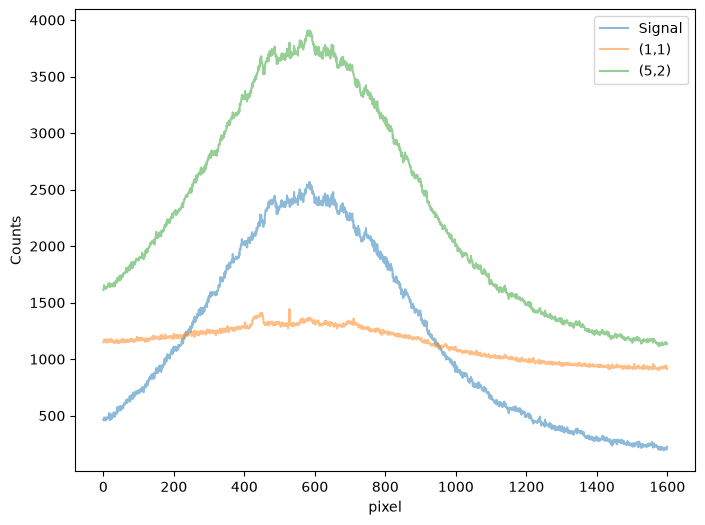

In [ ]:
# Now I want to do WSe2-CIPS/WSe2. So (2,5)-(1,1)

x_data = xr_data['camera_pixel_x_axis'].values
y_matrix = xr_data['camera_spectrum'].values

#Create the figure outside the loop to plot both spectra in the same figure
fig, ax = plt.subplots(figsize=(8, 6))
       
# ---Get the data ---
y_crudo = abs(y_matrix[1,1,:]-y_matrix[5,2,:])
y_11 = y_matrix[1,1,:]
y_52= y_matrix[5,2,:]

try:    
    ax.plot(x_data, y_crudo, label=f'Signal')
    ax.plot(x_data, y_11, label = f'(1,1)')
    ax.plot(x_data, y_52, label = f'(5,2)')
    #ax.plot(x_zone, y_fit, linewidth=2, label=f'Fit  | R²={r2:.3f}')

except RuntimeError:
    print(f"Curve fit failed.")


ax.set_xlabel("pixel")
ax.set_ylabel("Counts")
ax.legend()            
plt.show()

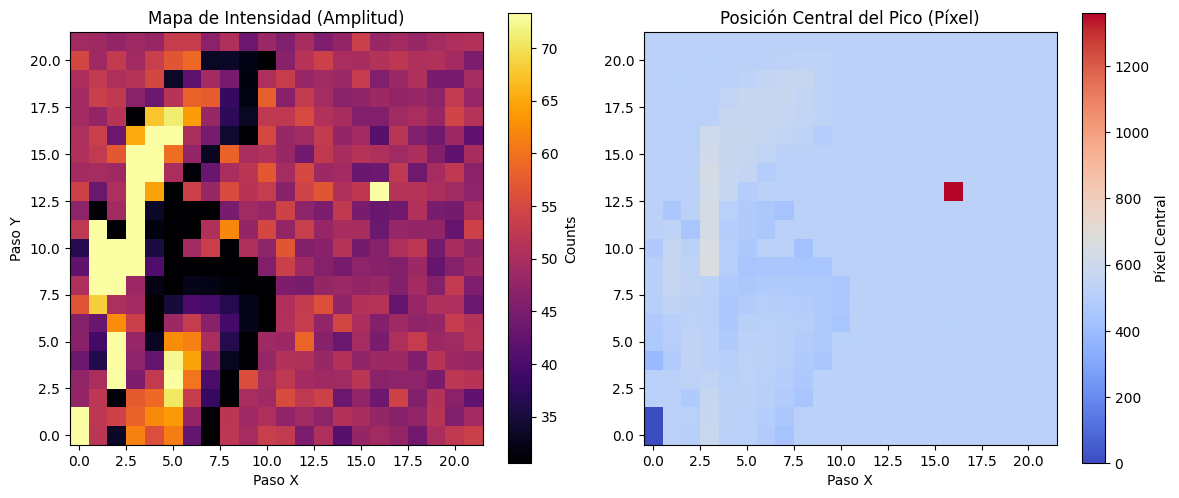

In [ ]:
#this was the first try at mapping the results, later on I decided to do a python script as it seemed cleaner that way.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

limit_up = np.nanpercentile(intensity_map, 95)
limit_down = np.nanpercentile(intensity_map, 5)

im1 = ax1.imshow(intensity_map, cmap='inferno', origin='lower', vmax=limit_up, vmin=limit_down)
ax1.set_title("Mapa de Intensidad (Amplitud)")
ax1.set_xlabel("Paso X")
ax1.set_ylabel("Paso Y")
fig.colorbar(im1, ax=ax1, label="Counts")

# --- Mapa 2: Posición del Pico (Desplazamiento / Strain) ---
# Usamos un colormap divergente como 'coolwarm' para ver giros hacia el rojo o azul
im2 = ax2.imshow(position_map, cmap='coolwarm', origin='lower')
ax2.set_title("Posición Central del Pico (Píxel)")
ax2.set_xlabel("Paso X")
fig.colorbar(im2, ax=ax2, label="Píxel Central")

plt.tight_layout()
plt.show()
